1. Introduction

In this notebook, I build a deep learning model that analyzes dashboard images
and checks whether they follow IBCS (International Business Communication Standards).

The model focuses on four key rules:
- Actual (AC)
- Previous Year (PY)
- Plan (PL)
- Forecast (FC)

Each rule is predicted separately using a multi-label classification approach.

The goal is not only to classify dashboards, but also to explain why a rule
is correct or incorrect using business-oriented feedback.


2. Import Libraries

In [28]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms, models

from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix

Several Python libraries are imported to support image processing, model training, and evaluation. PyTorch is used to build and train the neural network model, while Pandas is used for reading and managing the dataset. Matplotlib helps visualize training results and model performance.

3. Configuration

In [29]:
# Dataset path
data_dir = "../images_data"

# Image settings
IMG_SIZE = 224

# Training settings
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 0.0001

# Early stopping
PATIENCE = 5

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cpu


This section defines the main configuration settings for the project. The image size is set to 224x224 pixels because this is the standard input size for ResNet18. The batch size controls how many images are processed at once, while the learning rate controls how quickly the model updates its weights during training.

Early stopping is also configured to prevent overfitting if validation performance stops improving.

4. Load Dataset

In [30]:
df = pd.read_csv("../images_data/labels-correct.csv", sep=";")


def _image_path_exists(relative_path, root):
    """Same resolution rules as MultiLabelDataset._resolve_image_path."""
    clean_relative = relative_path.replace("\\", "/").strip()
    img_path = os.path.normpath(os.path.join(root, clean_relative))
    if os.path.exists(img_path):
        return True
    base, _ = os.path.splitext(img_path)
    for ext in [".png", ".jpg", ".jpeg", ".webp"]:
        if os.path.exists(base + ext):
            return True
    return False


_before = len(df)
df = df[
    df["image"].apply(lambda p: _image_path_exists(p, data_dir))
].reset_index(drop=True)
print(f"Using {len(df)} rows with image files under {data_dir} (skipped {_before - len(df)} missing paths).")

for col in ["AC", "PY", "PL", "FC"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
_bad = df[["AC", "PY", "PL", "FC"]].isna().any(axis=1).sum()
df = df.dropna(subset=["AC", "PY", "PL", "FC"]).reset_index(drop=True)
if _bad:
    print(f"Dropped {_bad} rows with non-numeric labels (e.g. placeholders).")

df.head(10)

Using 40 rows with image files under ../images_data (skipped 319 missing paths).


,image,AC,PY,PL,FC
0,compliant/1.png,1,0,0,0
1,compliant/2.png,1,1,0,0
2,compliant/3.png,1,1,1,0
3,compliant/4.png,1,1,1,0
4,compliant/5.png,1,1,1,1
5,compliant/6.png,1,1,1,1
6,compliant/7.png,1,1,1,1
7,compliant/8.png,1,0,0,0
8,compliant/9.png,1,1,1,1
9,compliant/10.png,1,1,1,1


The dataset labels are stored in a CSV file. Each image contains four labels representing the IBCS rules: Actual, Previous Year, Plan, and Forecast.


Each label uses:


1 = correct

0 = incorrect

This structure allows the model to learn every rule independently using multi-label classification.

5. Data Augmentation

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomRotation(5),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

Data augmentation creates slightly modified versions of the training images. Small changes such as rotation, flipping, and brightness adjustments help the model learn more general visual patterns.

This reduces overfitting and improves the model’s ability to work with unseen dashboard images.

6. Dataset Class

In [32]:
class MultiLabelDataset(Dataset):

    def __init__(self, data_dir, dataframe, transform=None):
        self.data_dir = data_dir
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, relative_path):

        clean_relative = relative_path.replace("\\", "/").strip()

        img_path = os.path.normpath(
            os.path.join(self.data_dir, clean_relative)
        )

        if os.path.exists(img_path):
            return img_path

        base, _ = os.path.splitext(img_path)

        for ext in [".png", ".jpg", ".jpeg", ".webp"]:
            candidate = base + ext

            if os.path.exists(candidate):
                return candidate

        raise FileNotFoundError(f"Image not found: {relative_path}")

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = self._resolve_image_path(row["image"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor([
            row["AC"],
            row["PY"],
            row["PL"],
            row["FC"]
        ], dtype=torch.float32)

        return image, label

This custom dataset class is responsible for loading images and their labels. It reads image paths from the CSV file and converts each image into a format that can be processed by the neural network.

Each dashboard image receives four labels, allowing the model to predict all IBCS rules separately.

7. Create Dataset

In [33]:
full_dataset = MultiLabelDataset(
    data_dir=data_dir,
    dataframe=df,
    transform=train_transform
)

The full dataset is created using the custom dataset class. Training transformations are applied to improve generalization and reduce overfitting during model training.

8. Split Dataset

In [34]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

The dataset is divided into training, validation, and test sets. The training set is used for learning, the validation set monitors performance during training, and the test set evaluates final model performance on unseen data.

This separation helps ensure fair and reliable evaluation.

9. Apply Test Transform to Validation and Test

In [35]:
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

Validation and test images should not use augmentation because the goal is to evaluate real model performance. Therefore, only resizing and tensor conversion are applied.

10. DataLoaders

In [36]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

DataLoaders divide the dataset into smaller batches. This improves memory efficiency and speeds up the training process. Shuffling is enabled for the training data so the model learns from different image orders during each epoch.

11. Visualize Sample Images

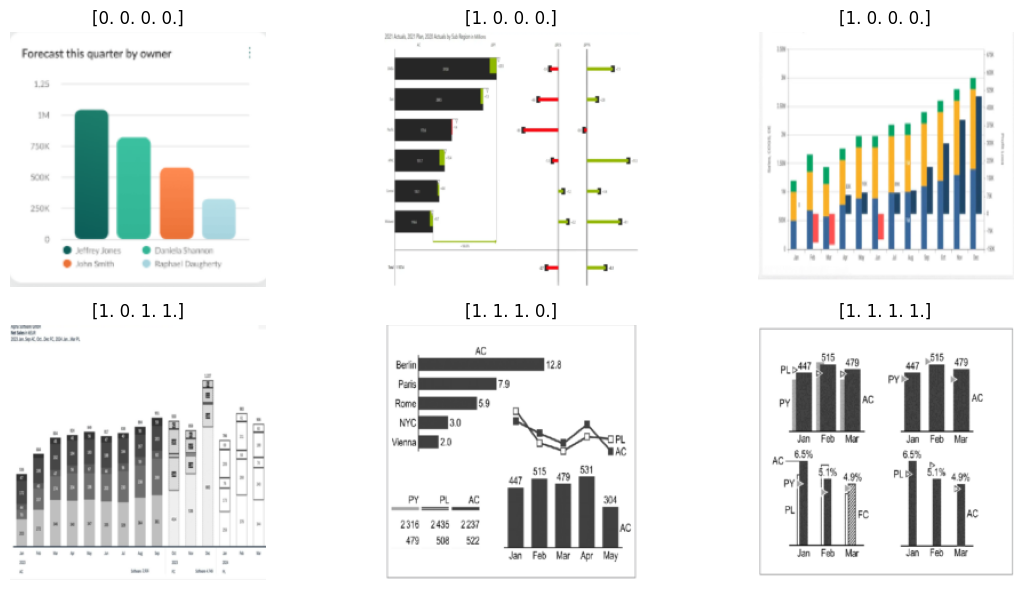

In [37]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    img = images[i].permute(1, 2, 0)

    plt.imshow(img)

    plt.title(labels[i].numpy())

    plt.axis("off")

plt.tight_layout()
plt.show()

This section visualizes sample dashboard images from the dataset. Displaying images helps verify that preprocessing and augmentation are working correctly before training begins.

12. Build Model (Transfer Learning)

In [38]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

model.fc = nn.Sequential(
    nn.Dropout(0.3),

    nn.Linear(
        model.fc.in_features,
        4
    )
)

model = model.to(DEVICE)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

A pretrained ResNet18 model is used through transfer learning. Since ResNet18 was trained on millions of images, it already understands many visual features such as shapes, colors, and patterns.

The final classification layer is replaced with a new layer containing four outputs, one for each IBCS rule. A dropout layer is added to reduce overfitting.

13. Loss Function and Optimizer

In [39]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

Because this is a multi-label classification problem, BCEWithLogitsLoss is used. This loss function evaluates every rule independently.

The Adam optimizer is used because it trains neural networks efficiently and adapts learning automatically during training.

14. Training Function

In [40]:
def calculate_accuracy(outputs, labels):

    preds = (torch.sigmoid(outputs) > 0.5).float()

    accuracy = (preds == labels).float().mean()

    return accuracy.item()

This function calculates prediction accuracy during training. The model outputs probabilities, which are converted into binary predictions using a threshold of 0.5.

The accuracy measures how many rule predictions are correct.

15. Training Loop with Early Stopping

In [41]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")

patience_counter = 0

best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # -----------------------------
    # TRAINING
    # -----------------------------

    model.train()

    train_loss = 0
    train_acc = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        train_acc += calculate_accuracy(outputs, labels)

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    # -----------------------------
    # VALIDATION
    # -----------------------------

    model.eval()

    val_loss = 0
    val_acc = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            val_acc += calculate_accuracy(outputs, labels)

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)

    # -----------------------------
    # SAVE HISTORY
    # -----------------------------

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

    # -----------------------------
    # EARLY STOPPING
    # -----------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(
            model.state_dict(),
            "ibcs_final_model.pth"
        )

        print("Best model saved!")

        patience_counter = 0

    else:

        patience_counter += 1

        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:

            print("Early stopping triggered!")

            break


Epoch 1/30
Train Loss: 0.8162
Validation Loss: 0.6900
Train Accuracy: 0.4089
Validation Accuracy: 0.4583
Best model saved!

Epoch 2/30
Train Loss: 0.5539
Validation Loss: 0.6292
Train Accuracy: 0.7292
Validation Accuracy: 0.7083
Best model saved!

Epoch 3/30
Train Loss: 0.3570
Validation Loss: 0.5480
Train Accuracy: 0.9401
Validation Accuracy: 0.7500
Best model saved!

Epoch 4/30
Train Loss: 0.2466
Validation Loss: 0.4759
Train Accuracy: 0.9896
Validation Accuracy: 0.8750
Best model saved!

Epoch 5/30
Train Loss: 0.2127
Validation Loss: 0.4230
Train Accuracy: 0.9714
Validation Accuracy: 0.9167
Best model saved!

Epoch 6/30
Train Loss: 0.1484
Validation Loss: 0.3891
Train Accuracy: 1.0000
Validation Accuracy: 0.8750
Best model saved!

Epoch 7/30
Train Loss: 0.1129
Validation Loss: 0.3661
Train Accuracy: 0.9922
Validation Accuracy: 0.8750
Best model saved!

Epoch 8/30
Train Loss: 0.1105
Validation Loss: 0.3480
Train Accuracy: 0.9792
Validation Accuracy: 0.8750
Best model saved!

Epoch 9

The training loop teaches the model to recognize IBCS patterns from dashboard images. During each epoch, the model predicts labels, calculates errors, and updates its internal weights.

Validation is performed after every epoch to monitor performance on unseen data. Early stopping is used to stop training automatically if validation loss no longer improves. This prevents overfitting and saves the best-performing model.

16. Load Best Model

In [42]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

After training is completed, the best saved model weights are loaded. This ensures that the final model uses the highest-performing version found during training.

17. Plot Training Results

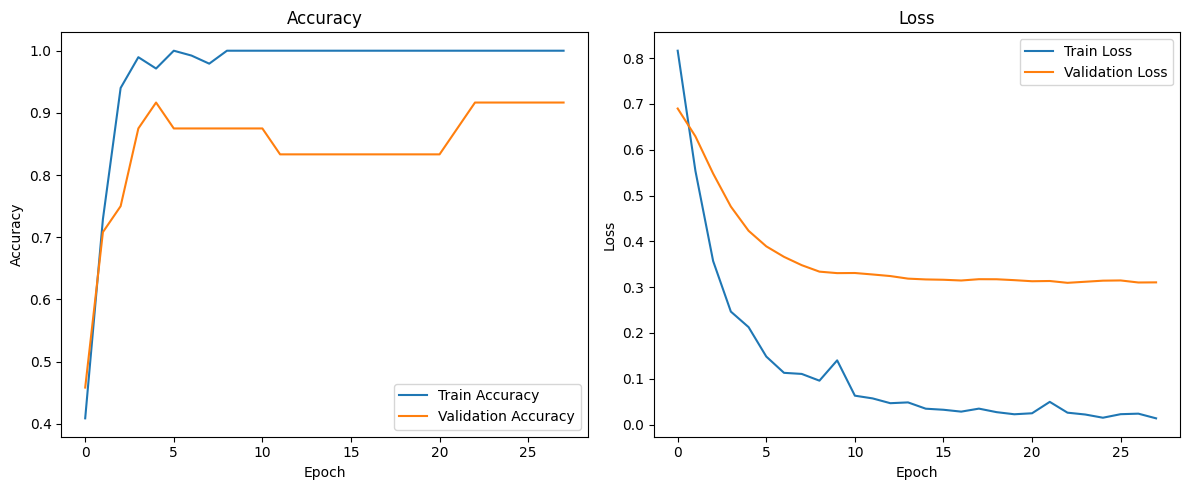

In [43]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# Loss
plt.subplot(1, 2, 2)

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()

These graphs visualize the learning process of the model. Accuracy graphs show how prediction performance improves during training, while loss graphs show how prediction errors decrease over time.

Comparing training and validation curves also helps identify possible overfitting.

18. Evaluate Model

In [44]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())

The trained model is evaluated using the test dataset. Predictions are generated for unseen dashboard images, allowing final performance measurement.

18.1 Final Test Accuracy

In [45]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        correct += (preds == labels).sum().item()

        total += labels.numel()

final_accuracy = correct / total

print(f"Final Test Accuracy: {final_accuracy:.4f}")

Final Test Accuracy: 0.7083


19. Classification Report

In [46]:
rule_names = ["AC", "PY", "PL", "FC"]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=rule_names
    )
)

              precision    recall  f1-score   support

          AC       1.00      0.60      0.75         5
          PY       0.00      0.00      0.00         2
          PL       1.00      0.67      0.80         3
          FC       0.50      0.50      0.50         2

   micro avg       0.86      0.50      0.63        12
   macro avg       0.62      0.44      0.51        12
weighted avg       0.75      0.50      0.60        12
 samples avg       0.44      0.32      0.34        12



C:\Users\qawsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\qawsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\qawsa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

The classification report shows detailed evaluation metrics such as precision, recall, and F1-score for each IBCS rule. These metrics provide a more complete understanding of model performance than accuracy alone.

20. Rule Explanations (Feedback)

In [47]:
RULE_EXPLANATIONS = {

    "AC": {

        "correct":
        "Actual is correct because the dashboard uses a dark solid color, which follows IBCS standards for actual values.",

        "incorrect":
        "Actual is incorrect because the dashboard does not use a dark solid color. According to IBCS standards, actual values should be clearly emphasized using dark solid colors."
    },

    "PY": {

        "correct":
        "Previous Year is correct because the visual style is lighter than Actual values, making historical comparisons easier.",

        "incorrect":
        "Previous Year is incorrect because the color is not lighter than Actual values. IBCS recommends lighter colors for historical data."
    },

    "PL": {

        "correct":
        "Plan is correct because the dashboard uses outlined shapes, which is the recommended IBCS style for planned values.",

        "incorrect":
        "Plan is incorrect because the dashboard uses filled shapes instead of outlined shapes. IBCS standards recommend outlined visuals for planned values."
    },

    "FC": {

        "correct":
        "Forecast is correct because the dashboard uses a hatched or patterned style, which follows IBCS standards for forecast values.",

        "incorrect":
        "Forecast is incorrect because the dashboard does not use a hatched pattern. According to IBCS standards, forecast values should use a patterned style."
    }
}

This dictionary contains business explanations for each IBCS rule. The system provides different feedback depending on whether a rule is predicted as correct or incorrect.

This makes the model more useful because users receive understandable business feedback instead of only technical predictions.

21. Prediction Function

In [48]:
def predict_dashboard(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    image_tensor = test_transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        outputs = model(image_tensor)

        probs = torch.sigmoid(outputs).cpu().numpy()[0]

    rule_names = ["AC", "PY", "PL", "FC"]

    for i, rule in enumerate(rule_names):

        confidence = probs[i] * 100

        if probs[i] >= 0.5:

            status = "Correct"

            explanation = RULE_EXPLANATIONS[rule]["correct"]

        else:

            status = "Incorrect"

            explanation = RULE_EXPLANATIONS[rule]["incorrect"]

        print(f"\n{rule}")
        print(f"Status: {status}")
        print(f"Confidence: {confidence:.2f}%")
        print(f"Explanation: {explanation}")

This function loads a dashboard image and predicts all four IBCS rules. The model also provides confidence scores and detailed explanations for every prediction.

This allows users to understand both the result and the reasoning behind it.

22. Test Prediction

In [54]:
test_image = "../images_data/compliant/1.png"
test_image = "../images_data/non-compliant/6.png"

predict_dashboard(test_image)


AC
Status: Correct
Confidence: 96.77%
Explanation: Actual is correct because the dashboard uses a dark solid color, which follows IBCS standards for actual values.

PY
Status: Incorrect
Confidence: 2.11%
Explanation: Previous Year is incorrect because the color is not lighter than Actual values. IBCS recommends lighter colors for historical data.

PL
Status: Incorrect
Confidence: 2.33%
Explanation: Plan is incorrect because the dashboard uses filled shapes instead of outlined shapes. IBCS standards recommend outlined visuals for planned values.

FC
Status: Incorrect
Confidence: 2.49%
Explanation: Forecast is incorrect because the dashboard does not use a hatched pattern. According to IBCS standards, forecast values should use a patterned style.


A sample dashboard image is used to test the final prediction system. The output includes predicted rule status, confidence scores, and business explanations.

23. Save Final Model

In [56]:
torch.save(
    model.state_dict(),
    "ibcs_final_model.pth"
)

print("Final model saved successfully!")

Final model saved successfully!


The final trained model is saved as a .pth file. This allows the model to be reused later without retraining.

The saved model can later be integrated into a backend or web application.

24. Conclusion


The final model successfully detects IBCS scenario rules from dashboard images
using a multi-label deep learning approach.

The system predicts four different rules separately and generates meaningful
business feedback for each rule.

Transfer learning with ResNet18 improved the learning process, while data
augmentation and early stopping reduced overfitting and improved
generalization.

The model demonstrates the potential of AI-assisted dashboard validation and
can support future business intelligence applications.
